# Setup path

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

# Import

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Import project

In [3]:
from src.dominick import DominickDataLoader
from src.dominick.multiproduct_builder import MultiProductBuilder
from src.nn.data import DataLoaderFactory, ColumnEncoder         
from src.multiproduct import MultiProductDataset, MultiProductContextEmbeddings

from src.nn_baseline.models import ElasticityFieldMLP, Y0MLP, ElasticityFirstPredictor, BaselineModel
from src.nn_baseline.loss import ElasticityFirstLoss
from src.nn_baseline.diagnostics import ClosureDiagnostics, PathDependenceDiagnostics

# Loader

In [ ]:
loader = DominickDataLoader()
df = loader.load("elasticity_dataset.csv")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Dataset shape: (1966147, 10)
Columnas: ['store_code', 'upc_code', 'week_id', 'liters_per_upc', 'on_promo', 'promo_B', 'promo_C', 'promo_S', 'log_price_per_liter', 'log_liters_sold']


# Encoder

In [ ]:
# ── 1. Split temporal (con week_id original) ──────────────────────
sorted_weeks   = sorted(df["week_id"].unique())
week_threshold = sorted_weeks[int(len(sorted_weeks) * 0.8)]
train_df_raw   = df[df["week_id"] < week_threshold].copy()
val_df_raw     = df[df["week_id"] >= week_threshold].copy()

# ── 2. Pipeline multi-producto (UPCs originales) ──────────────────
mp_builder = MultiProductBuilder()
mp_builder.fit(train_df_raw, n=3)
n = mp_builder.n

train_wide = mp_builder.transform(train_df_raw)
val_wide   = mp_builder.transform(val_df_raw)

# ── 3. Encoding store/week sobre el df original (mapping consistente) ──
encoder = ColumnEncoder()
_, store_cats = encoder.factorize(df, "store_code", sort=True)
_, week_cats  = encoder.factorize(df, "week_id",    sort=True)

n_stores = len(store_cats)
n_weeks  = len(week_cats)

store_map = {v: i for i, v in enumerate(store_cats)}
week_map  = {v: i for i, v in enumerate(week_cats)}

for w in [train_wide, val_wide]:
    w["store_code"] = w["store_code"].map(store_map)
    w["week_id"]    = w["week_id"].map(week_map)

# ── 4. Dataset y DataLoaders ───────────────────────────────────────
train_dataset = MultiProductDataset(train_wide, n=n)
val_dataset   = MultiProductDataset(val_wide,   n=n)

loader_factory = DataLoaderFactory(batch_size=512, num_workers=4, pin_memory=True)
train_loader   = loader_factory.create_train_loader(train_dataset, shuffle=True, drop_last=True)
val_loader     = loader_factory.create_eval_loader(val_dataset, shuffle=False)

print(f"Train: {len(train_wide):,}  |  Val: {len(val_wide):,}")
print(f"UPCs selected: {mp_builder.selected_upcs}")
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

Train: 14,615  |  Val: 4,003
UPCs seleccionados: [1820000784, 3410010505, 7289000011]
Train batches: 28  |  Val batches: 8


# x0 Reference

In [6]:
week_min = float(train_wide["week_id"].min())
week_max = float(train_wide["week_id"].max())

x0 = torch.tensor(
    [float(train_wide[f"log_price_{i}"].mean()) for i in range(n)],
    dtype=torch.float32
)
print(f"x0: {x0.tolist()}")

x0: [0.5541308522224426, 0.47216540575027466, 1.0733752250671387]


# Context Builder

In [7]:
context_builder = MultiProductContextEmbeddings(
    n=n, n_stores=n_stores, n_weeks=n_weeks,
    d_store=24, d_week=12,
    fourier_period=52.0, fourier_harmonics=4,
    include_trend=True, week_min=week_min, week_max=week_max,
)
d_context = context_builder.out_dim
print(f"Context dimension: {d_context}")

Context dimension: 62


# Model Builder

In [ ]:
y0_model  = Y0MLP(n=n, d_context=d_context, hidden=128, depth=2, act="tanh", dropout=0.1)
E_model   = ElasticityFieldMLP(n=n, d_context=d_context, hidden=128, depth=2, act="tanh", dropout=0.05)
predictor = ElasticityFirstPredictor(E_model=E_model, y0_model=y0_model, x0=x0, steps_per_dim=16)

device = "cuda" if torch.cuda.is_available() else "cpu"
model  = BaselineModel(context_builder, predictor, n=n).to(device)   # ← añadir n=n
print(f"Device: {device}  |  Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Device: cuda  |  Parámetros totales: 56,844


# Loss

In [ ]:
loss_fn = ElasticityFirstLoss(
    huber_delta=1.0,
    lambda_cl=0.0,    # empieza en 0; activa después de warm-up
    lambda_pos=0.1,   # penaliza E_ii > 0 (ley de la demanda)
    reduction="none",
    closure_pair_subsample=None,
)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

scaler = torch.amp.GradScaler("cuda") if device == "cuda" else None
print("Config ready")

Configuración lista


# Training Loop

In [ ]:
n_epochs    = 25
best_val_loss = float("inf")
patience    = 4
patience_counter = 0
min_delta = 1e-4

history = {
    "train_loss": [], "train_fit": [], "train_pos": [], "train_closure": [],
    "val_loss": [], "val_mae": [], "val_mse": [], "lr": []
}

print("Starting training...")
print("=" * 80)

for epoch in range(n_epochs):

    # ── TRAIN ────────────────────────────────────────────────────────────────
    model.train()
    train_metrics = {"loss": 0., "fit": 0., "pos": 0., "closure": 0.}
    n_batches = 0

    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        y_true = torch.stack(
            [batch[f"log_liters_{i}"] for i in range(n)], dim=1
        )         # (B,)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda", enabled=(scaler is not None)):
            y_hat, x_nd, c = model(batch)          # (B,), (B,1), (B,d)
            loss_dict = loss_fn(
                y_hat=y_hat,          # (B,1)
                y_true=y_true,        # (B,1)
                x=x_nd,                             # (B,1)
                E_model=model.predictor.E_model,
                c=c,
            )

        if scaler is not None:
            scaler.scale(loss_dict["loss"]).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss_dict["loss"].backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        for k in train_metrics:
            train_metrics[k] += loss_dict[k].item()
        n_batches += 1

    train_metrics = {k: v / n_batches for k, v in train_metrics.items()}

    # ── VAL ──────────────────────────────────────────────────────────────────
    model.eval()
    val_losses, val_maes, val_mses = [], [], []

    with torch.no_grad():
        for batch in val_loader:
            batch  = {k: v.to(device) for k, v in batch.items()}
            y_true = torch.stack(
                [batch[f"log_liters_{i}"] for i in range(n)], dim=1
            )   

            y_hat, x, c = model(batch)
            loss_dict = loss_fn(
                y_hat=y_hat,
                y_true=y_true,
                x=x,
                E_model=model.predictor.E_model,
                c=c,
            )
            val_losses.append(loss_dict["loss"].item())
            val_maes.append((y_hat - y_true).abs().mean().item())
            val_mses.append(((y_hat - y_true) ** 2).mean().item())

    val_loss = float(np.mean(val_losses))
    val_mae  = float(np.mean(val_maes))
    val_mse  = float(np.mean(val_mses))

    # ── LOG ──────────────────────────────────────────────────────────────────
    for k, v in train_metrics.items():
        history[f"train_{k}"].append(v)
    history["val_loss"].append(val_loss)
    history["val_mae"].append(val_mae)
    history["val_mse"].append(val_mse)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{n_epochs}")
    print(f"  Train - Loss: {train_metrics['loss']:.4f}  Fit: {train_metrics['fit']:.4f}  "
          f"Pos: {train_metrics['pos']:.6f}  Closure: {train_metrics['closure']:.6f}")
    print(f"  Val   - Loss: {val_loss:.4f}  MAE: {val_mae:.4f}  MSE: {val_mse:.4f}")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")

    if val_loss < best_val_loss:
        improvement = best_val_loss - val_loss
        if improvement >= min_delta:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": best_val_loss,
                "x0": x0,
            }, "../models/best_baseline.pt")
            print(f"  -- Best model saved (val_loss: {best_val_loss:.4f})")
        else:
            patience_counter += 1
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping in epoch {epoch+1}")
            break
    print("-" * 80)

print(f"\nTraining completed  |  Best val_loss: {best_val_loss:.4f}")

Iniciando entrenamiento...
Epoch 1/25
  Train - Loss: 2.3652  Fit: 2.3641  Pos: 0.011001  Closure: 0.000000
  Val   - Loss: 0.8595  MAE: 0.6270  MSE: 0.6288
  LR: 0.001000
  ✓ Mejor modelo guardado (val_loss: 0.8595)
--------------------------------------------------------------------------------
Epoch 2/25
  Train - Loss: 0.6935  Fit: 0.6935  Pos: 0.000000  Closure: 0.000000
  Val   - Loss: 0.6328  MAE: 0.5206  MSE: 0.4542
  LR: 0.001000
  ✓ Mejor modelo guardado (val_loss: 0.6328)
--------------------------------------------------------------------------------
Epoch 3/25
  Train - Loss: 0.5773  Fit: 0.5773  Pos: 0.000038  Closure: 0.000000
  Val   - Loss: 0.5739  MAE: 0.4938  MSE: 0.4071
  LR: 0.001000
  ✓ Mejor modelo guardado (val_loss: 0.5739)
--------------------------------------------------------------------------------
Epoch 4/25
  Train - Loss: 0.5321  Fit: 0.5320  Pos: 0.000982  Closure: 0.000000
  Val   - Loss: 0.5672  MAE: 0.4908  MSE: 0.4007
  LR: 0.001000
  ✓ Mejor model

# Evaluation

In [ ]:
# Cargar mejor modelo
checkpoint = torch.load("../models/best_baseline.pt", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

all_preds        = []
all_targets      = []
all_elasticities = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        y_true = torch.stack(
            [batch[f"log_liters_{i}"] for i in range(n)], dim=1
        )                                               # (B, n)

        y_hat, x, c = model(batch)                     # (B, n), (B, n), (B, d)
        E = model.predictor.E_model(x, c)              # (B, n, n)
        eps = torch.diagonal(E, dim1=-2, dim2=-1)      # (B, n) elasticidades propias

        all_preds.append(y_hat.cpu())
        all_targets.append(y_true.cpu())
        all_elasticities.append(eps.cpu())

preds        = torch.cat(all_preds).numpy()        # (N, n)
targets      = torch.cat(all_targets).numpy()      # (N, n)
elasticities = torch.cat(all_elasticities).numpy() # (N, n)

# Métricas aplanando sobre todos los productos y observaciones
mae  = np.mean(np.abs(preds - targets))
mse  = np.mean((preds - targets) ** 2)
rmse = np.sqrt(mse)
r2   = 1 - (np.sum((targets - preds) ** 2) / np.sum((targets - targets.mean()) ** 2))

print("Final metrics in Validation:")
print(f"  MAE:  {mae:.4f}")
print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²:   {r2:.4f}")
print()
print("Own elasticities:")
print(f"  Media:       {elasticities.mean():.4f}")
print(f"  Mediana:     {np.median(elasticities):.4f}")
print(f"  Std:         {elasticities.std():.4f}")
print(f"  Min:         {elasticities.min():.4f}")
print(f"  Max:         {elasticities.max():.4f}")
print(f"  % Negativas: {(elasticities < 0).mean() * 100:.4f}%")

Métricas Finales en Validación:
  MAE:  0.4913
  MSE:  0.4015
  RMSE: 0.6337
  R²:   0.4306

Elasticidades propias:
  Media:       -2.3775
  Mediana:     -2.4997
  Std:         1.0524
  Min:         -5.0998
  Max:         0.9881
  % Negativas: 98.8925%


# Visualization

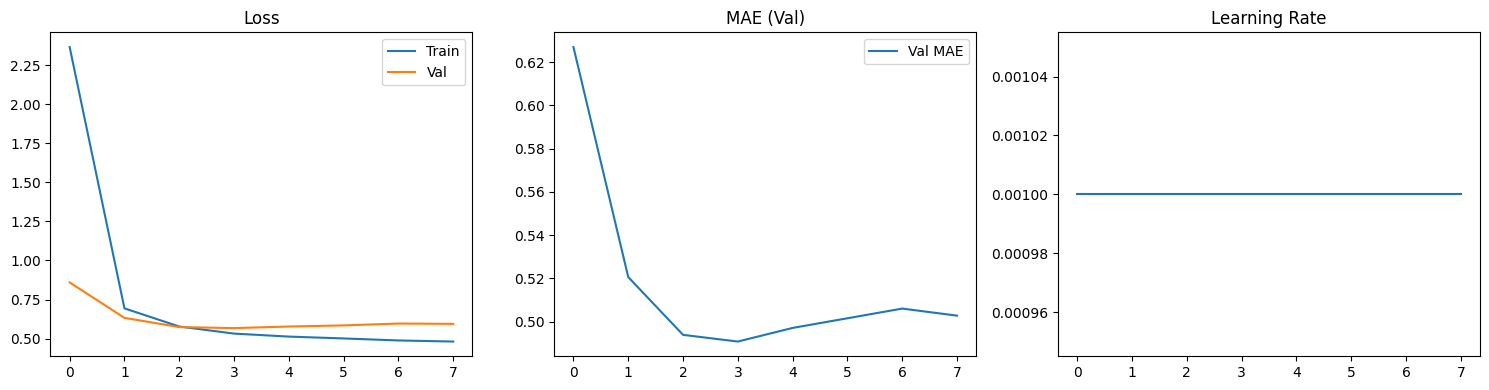

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["val_mae"], label="Val MAE")
axes[1].set_title("MAE (Val)")
axes[1].legend()

axes[2].plot(history["lr"])
axes[2].set_title("Learning Rate")

plt.tight_layout()
plt.show()

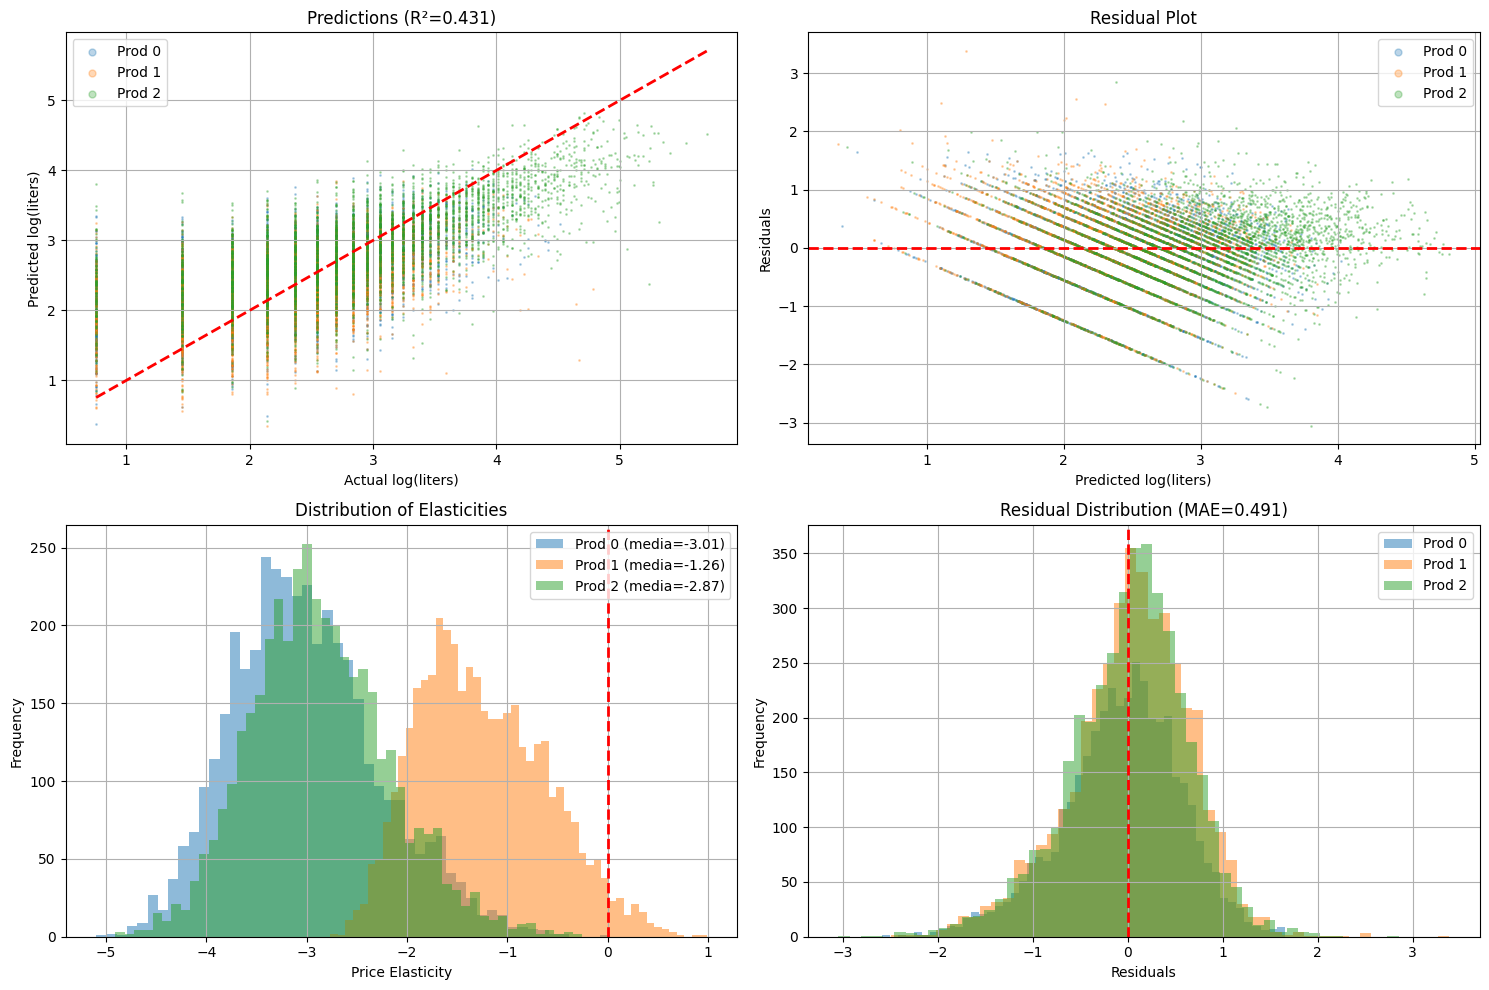


✓ Pipeline completado exitosamente


In [ ]:
colors = [cm.tab10(i) for i in range(n)]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Predicted vs Actual — por producto
for i in range(n):
    axes[0, 0].scatter(
        targets[:, i], preds[:, i],
        alpha=0.3, s=1, color=colors[i], label=f'Prod {i}'
    )
axes[0, 0].plot(
    [targets.min(), targets.max()],
    [targets.min(), targets.max()], 'r--', lw=2
)
axes[0, 0].set_xlabel('Actual log(liters)')
axes[0, 0].set_ylabel('Predicted log(liters)')
axes[0, 0].set_title(f'Predictions (R²={r2:.3f})')
axes[0, 0].legend(markerscale=5)
axes[0, 0].grid(True)

# Residual Plot — por producto
residuals = targets - preds   # (N, n)
for i in range(n):
    axes[0, 1].scatter(
        preds[:, i], residuals[:, i],
        alpha=0.3, s=1, color=colors[i], label=f'Prod {i}'
    )
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted log(liters)')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].legend(markerscale=5)
axes[0, 1].grid(True)

# Distribution of Elasticities — por producto
for i in range(n):
    axes[1, 0].hist(
        elasticities[:, i], bins=50, alpha=0.5,
        color=colors[i],
        label=f'Prod {i} (media={elasticities[:, i].mean():.2f})'
    )
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Price Elasticity')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Elasticities')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Residual Distribution — por producto
for i in range(n):
    axes[1, 1].hist(
        residuals[:, i], bins=50, alpha=0.5,
        color=colors[i], label=f'Prod {i}'
    )
axes[1, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title(f'Residual Distribution (MAE={mae:.3f})')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('../results/evaluation_plots.png', dpi=150)
plt.show()

print("\n✓ Pipeline completed successfully")

# Diagnostics

In [ ]:
# ── Closure residual ─────────────────────────────────────────────────────────
model.eval()
closure_diag = ClosureDiagnostics()
cl_penalties = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        _, x_nd, c = model(batch)
        out = closure_diag.run(E_model=model.predictor.E_model, x=x_nd, c=c)
        cl_penalties.append(out.penalty.item())

print(f"Closure residual mean (val): {np.mean(cl_penalties):.6f}")

Closure residual medio (val): 0.103015


In [ ]:
# ── Path dependence ──────────────────────────────────────────────────────────
pd_diag = PathDependenceDiagnostics(steps_per_dim=16)
pd_scores = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        y_hat, x_nd, c = model(batch)

        B = x_nd.shape[0]
        x0_batch = x0.to(device).unsqueeze(0).expand(B, -1)  # (B, 1)
        y0_batch = model.predictor.y0_model(c, batch_size=B)  # (B, 1)

        score = pd_diag.run(
            E_model=model.predictor.E_model,
            x0=x0_batch,
            y0=y0_batch,
            xT=x_nd,
            c=c,
        )
        pd_scores.append(score.item())

print(f"Path dependence mean (val): {np.mean(pd_scores):.6f}")

Path dependence medio (val): 0.002620
